In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('/content/Wine Quality.xlsx')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
# statistical info
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [4]:
# datatype info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## **Preprocessing the dataset**

In [5]:
# check for null values
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Como podemos ver no existen valores nulos (este casi nunca es el caso). Si existieran, en este caso podriamos usar el valor medio de cada columna para rellenar estos nulos si fueran pocos. Si fueran muchos más los nulos, entonces usaría otro tipo de método para dicha situación particular. Me interesa dejar escrito el código en cualquiera de los casos.

In [ ]:
#Esta linea de codigo rellena los nulos de la columna con el valor medio de dicha columna
for col, value in df.items():
  if col != 'type':
    df[col] = df[col].fillna(df[col].mean())

## **Exploratory Data Analysis**

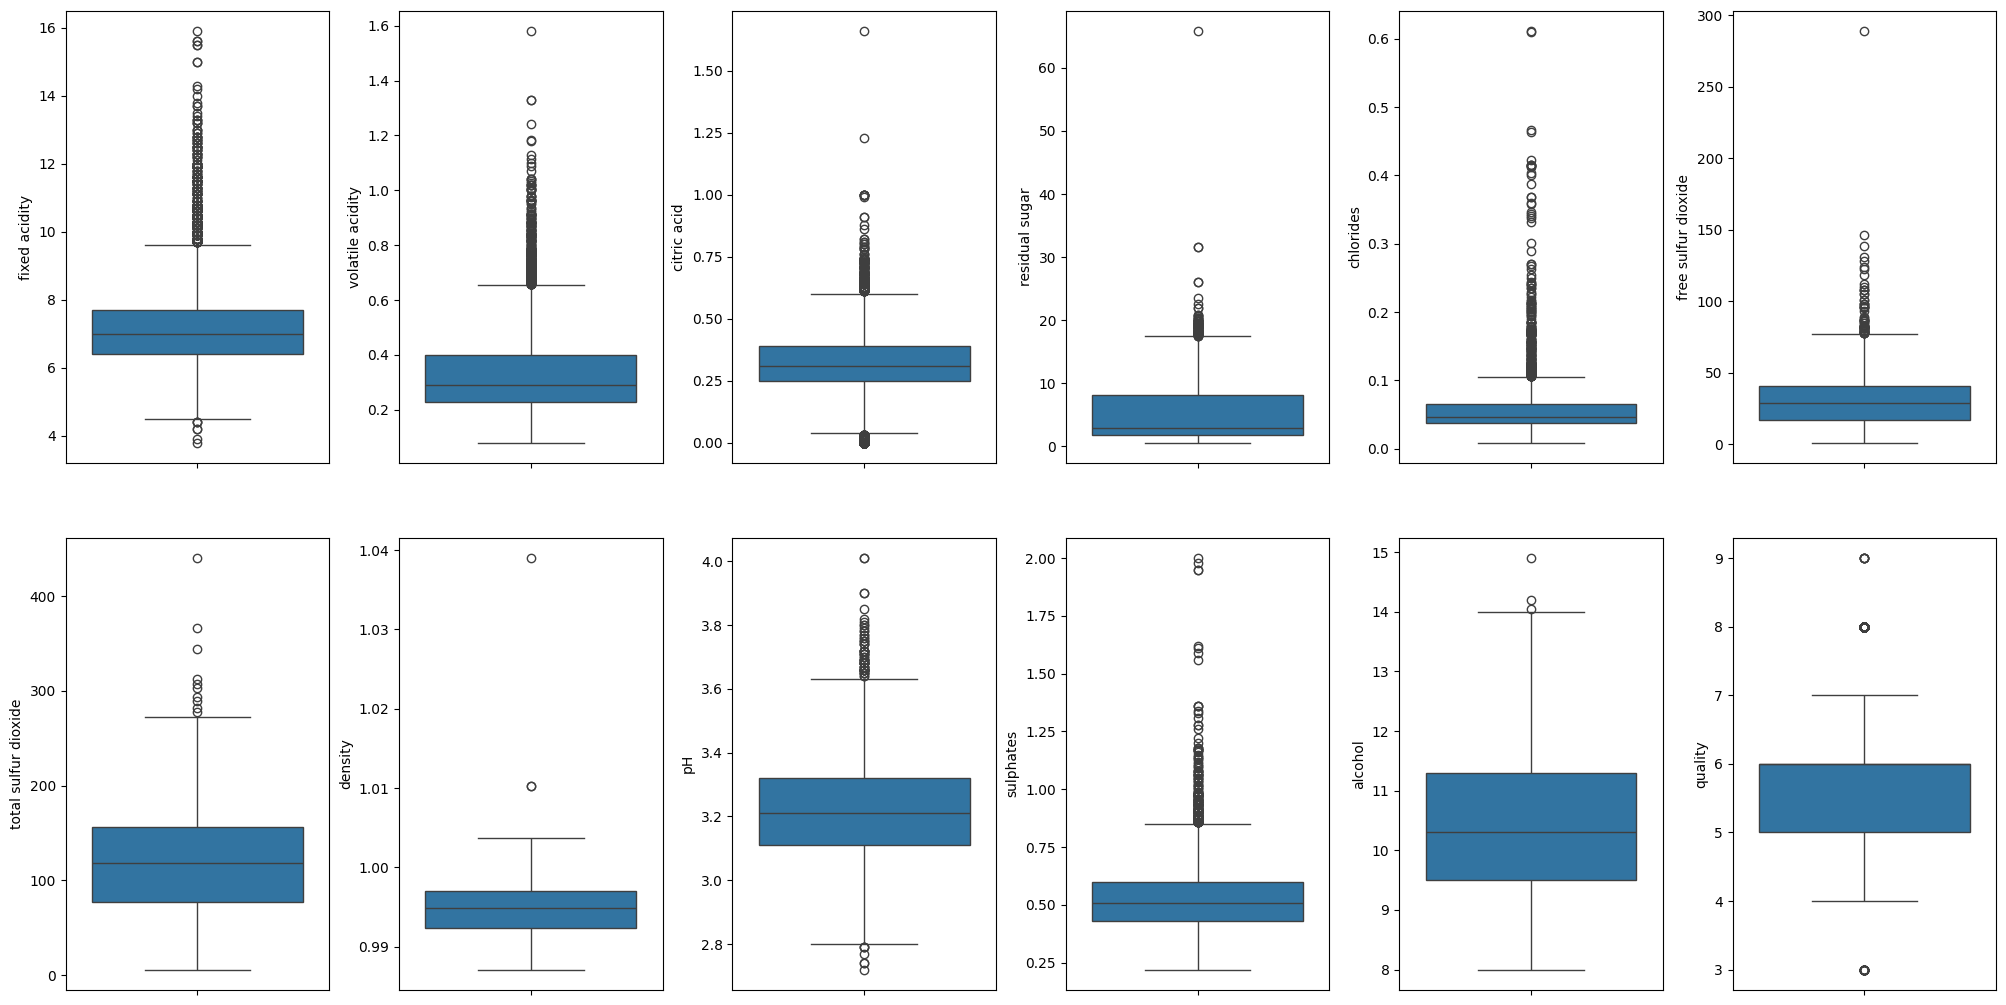

In [6]:
# create box plots
fig, ax = plt.subplots(ncols=6, nrows=2, figsize=(20,10))
index = 0
ax = ax.flatten()

for col, value in df.items(): # Call the items() method to iterate
  if col != 'color':
    sns.boxplot(y=col, data=df, ax=ax[index])
    index += 1

plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)
plt.show()

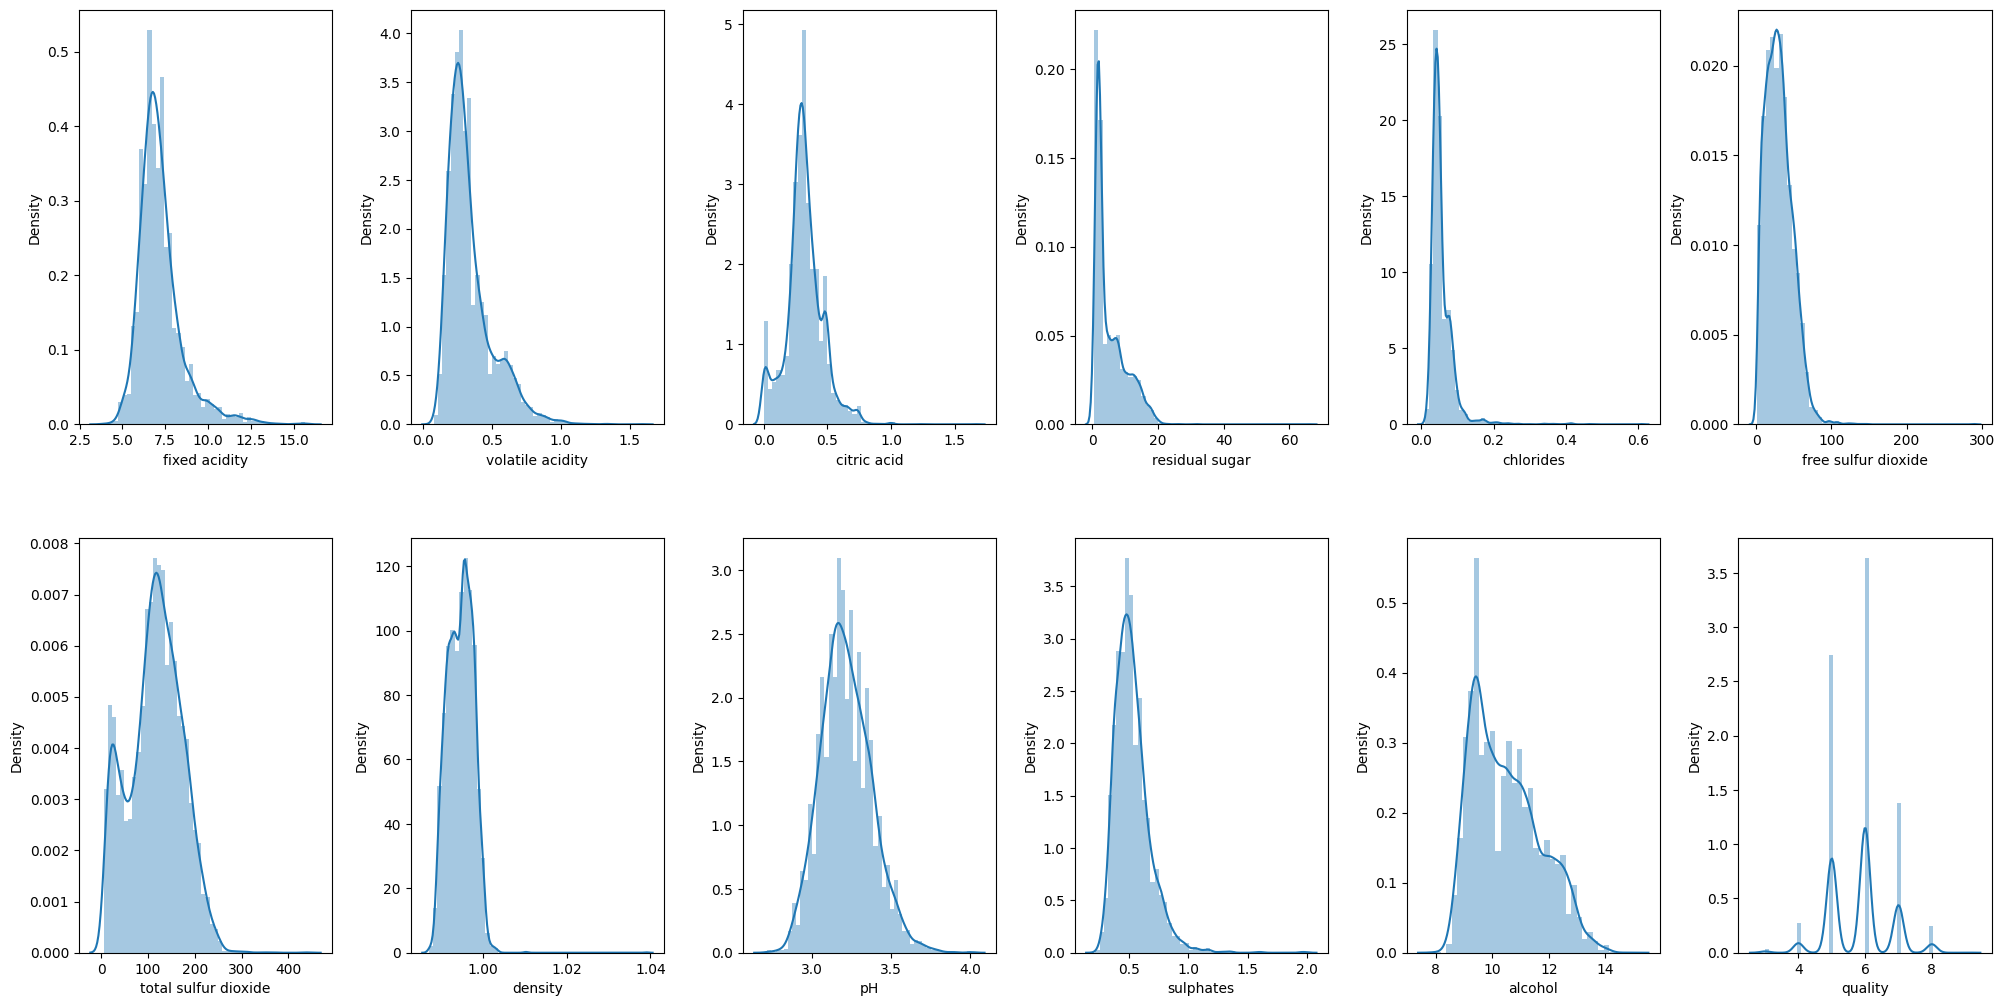

In [7]:
# create a dist plot
fig, ax = plt.subplots(ncols=6, nrows=2, figsize=(20,10))
index = 0
ax = ax.flatten()

for col, value in df.items(): # Call the items() method to iterate
  if col != 'color':
    sns.distplot(value, ax=ax[index])
    index += 1

plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)
plt.show()

In [8]:
# log transformation
df['free sulfur dioxide'] = np.log(1+df['free sulfur dioxide'])

<Axes: xlabel='free sulfur dioxide', ylabel='Density'>

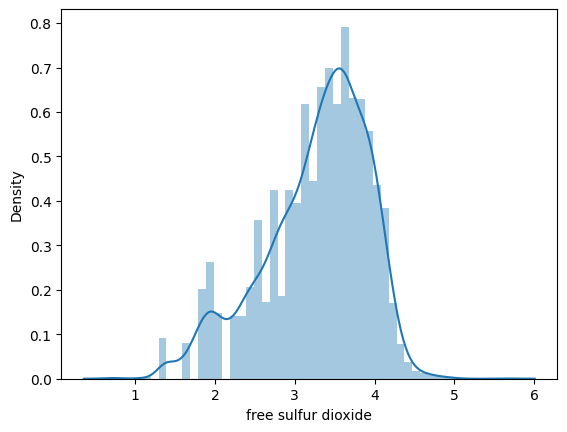

In [9]:
sns.distplot(df['free sulfur dioxide'])

In [10]:
df['quality'] = pd.to_numeric(df['quality'], errors='coerce')

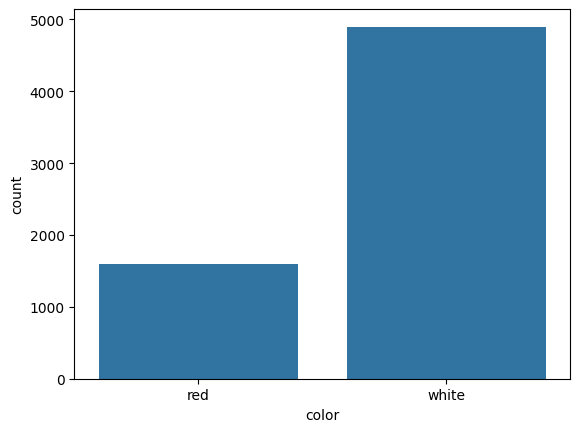

In [11]:
sns.countplot(x='color', data=df)
plt.show()

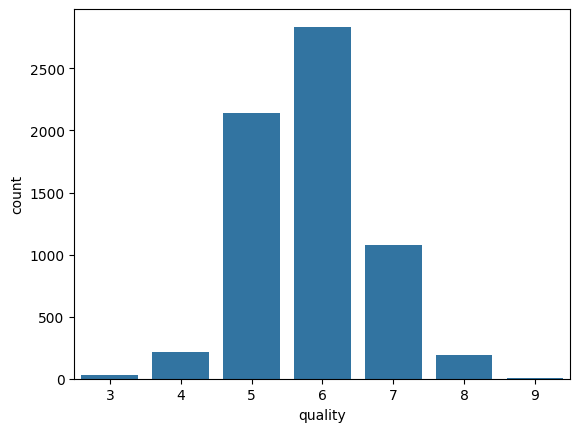

In [12]:
sns.countplot(x='quality', data=df)
plt.show()

## **Correlation Matrix**

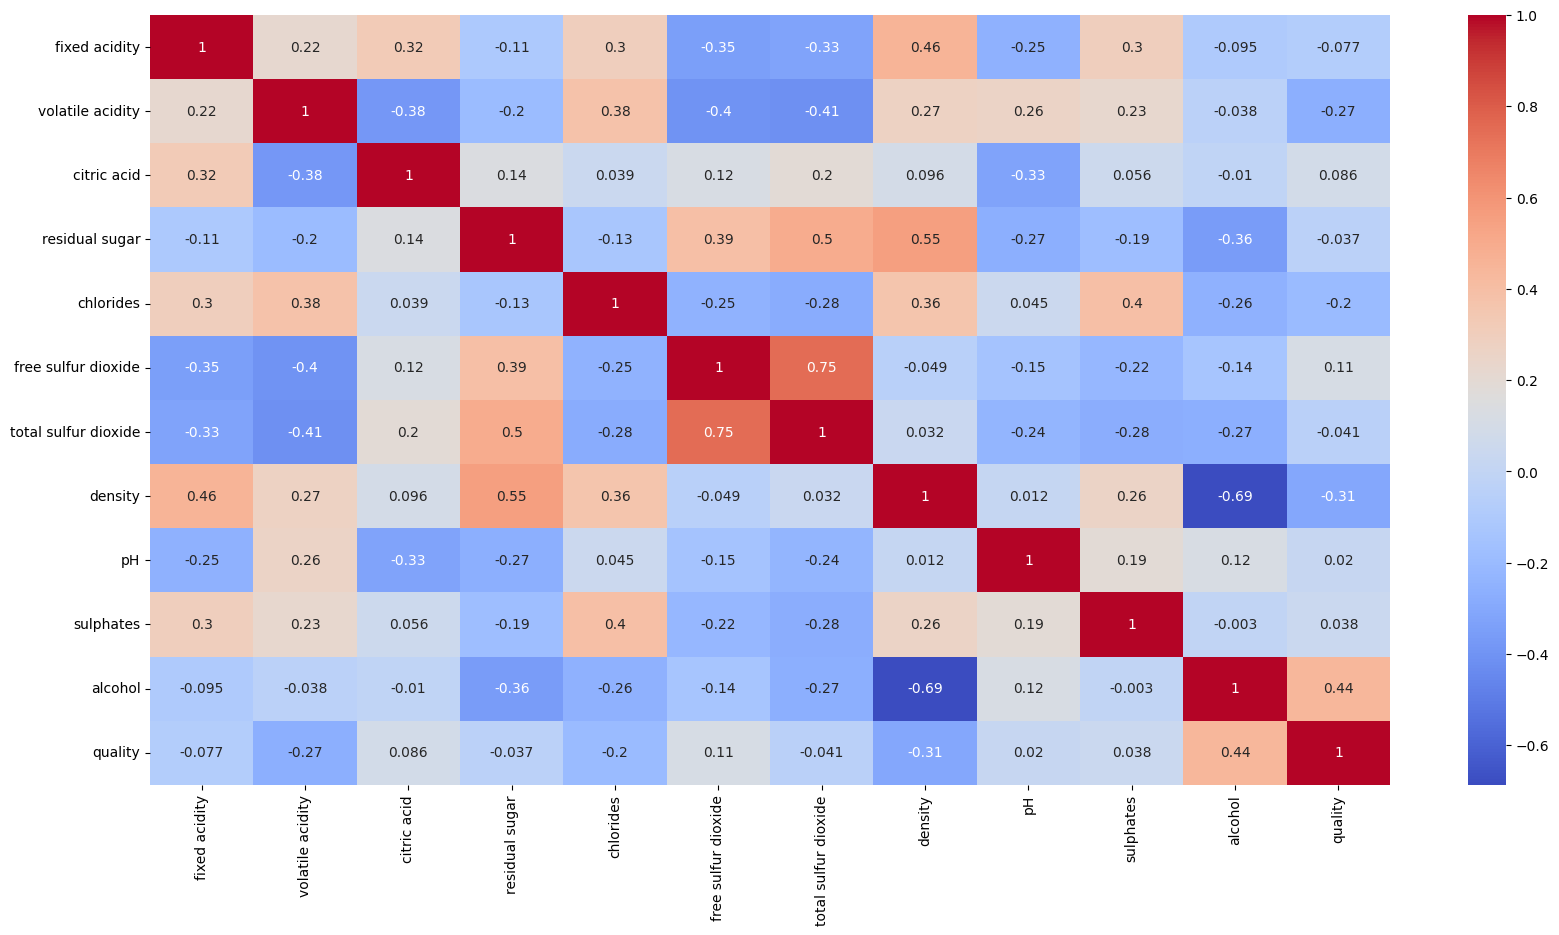

In [13]:
corr = df.drop('color', axis=1).corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

La presencia de Outliers ha sido detectada, por lo tanto voy a eliminarlos

## **REMOVING OUTLIERS**

In [14]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,3.267236,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,0.655486,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,0.693147,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,2.890372,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,3.401197,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,3.737670,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,5.669881,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [15]:
# Copiamos el dataset original
df_clean = df.copy()

# Definimos las columnas donde queremos revisar outliers
cols_outliers = ['residual sugar', 'chlorides', 'free sulfur dioxide',
                 'total sulfur dioxide', 'sulphates']

# Paso 1: Reemplazamos los outliers por NaN (sin eliminar filas)
for col in cols_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Convertir valores fuera de rango en NaN
    df_clean.loc[(df_clean[col] < lower) | (df_clean[col] > upper), col] = None

# Paso 2: Rellenamos esos NaN con la media de cada columna
df_clean[cols_outliers] = df_clean[cols_outliers].fillna(df_clean[cols_outliers].mean())

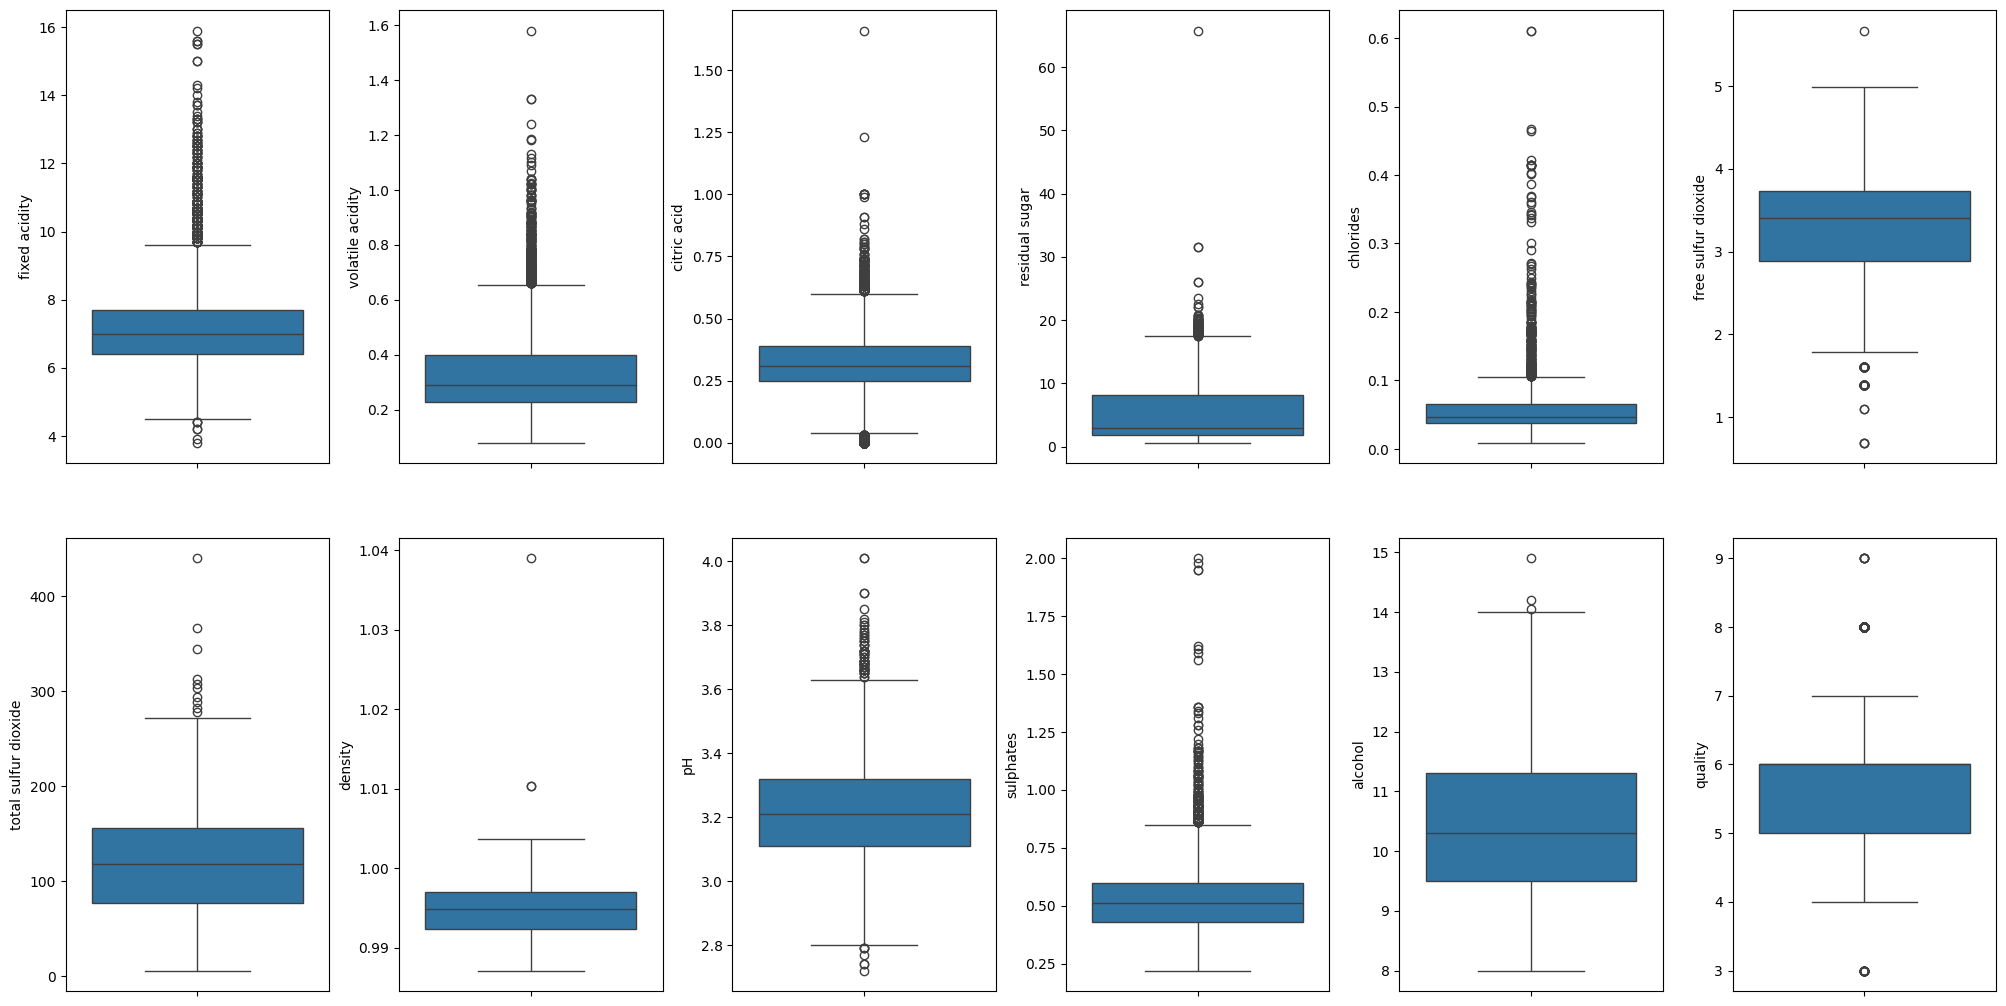

In [16]:
fig, ax = plt.subplots(ncols=6, nrows=2, figsize=(20,10))
index = 0
ax = ax.flatten()

for col, value in df.items(): # Call the items() method to iterate
  if col != 'color':
    sns.boxplot(y=col, data=df, ax=ax[index])
    index += 1

plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)
plt.show()

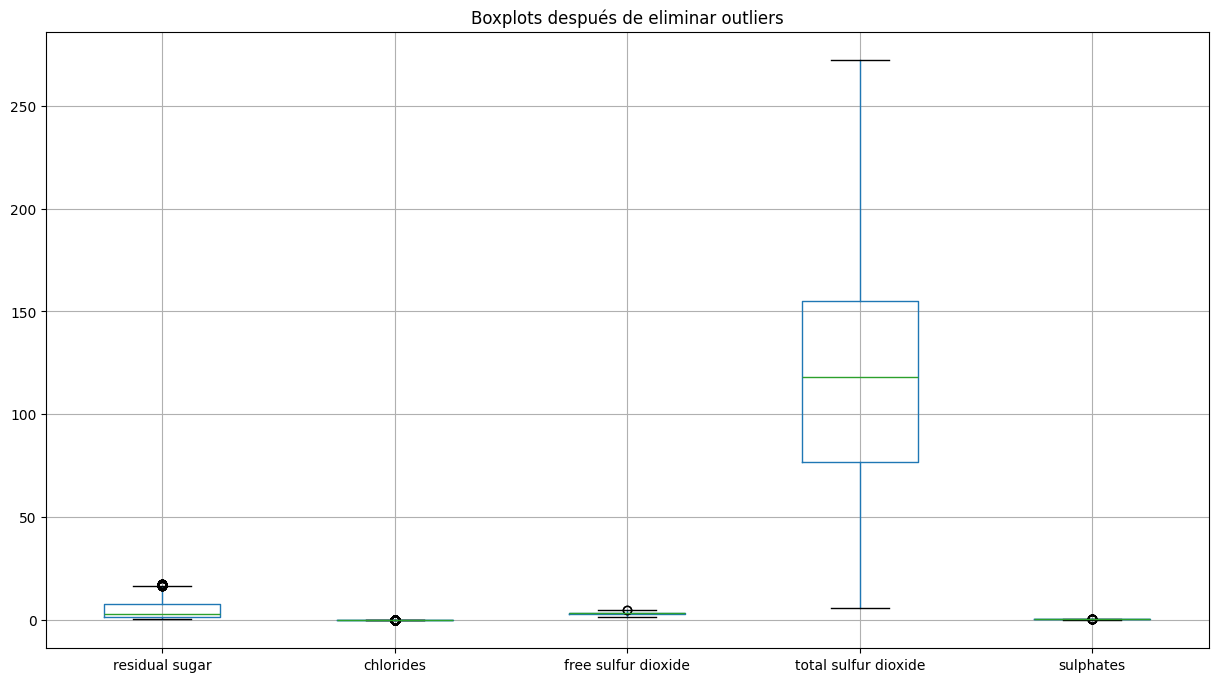

In [17]:
df_clean[cols_outliers].boxplot(figsize=(15, 8))
plt.title("Boxplots después de eliminar outliers")
plt.show()

In [18]:
df_clean.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


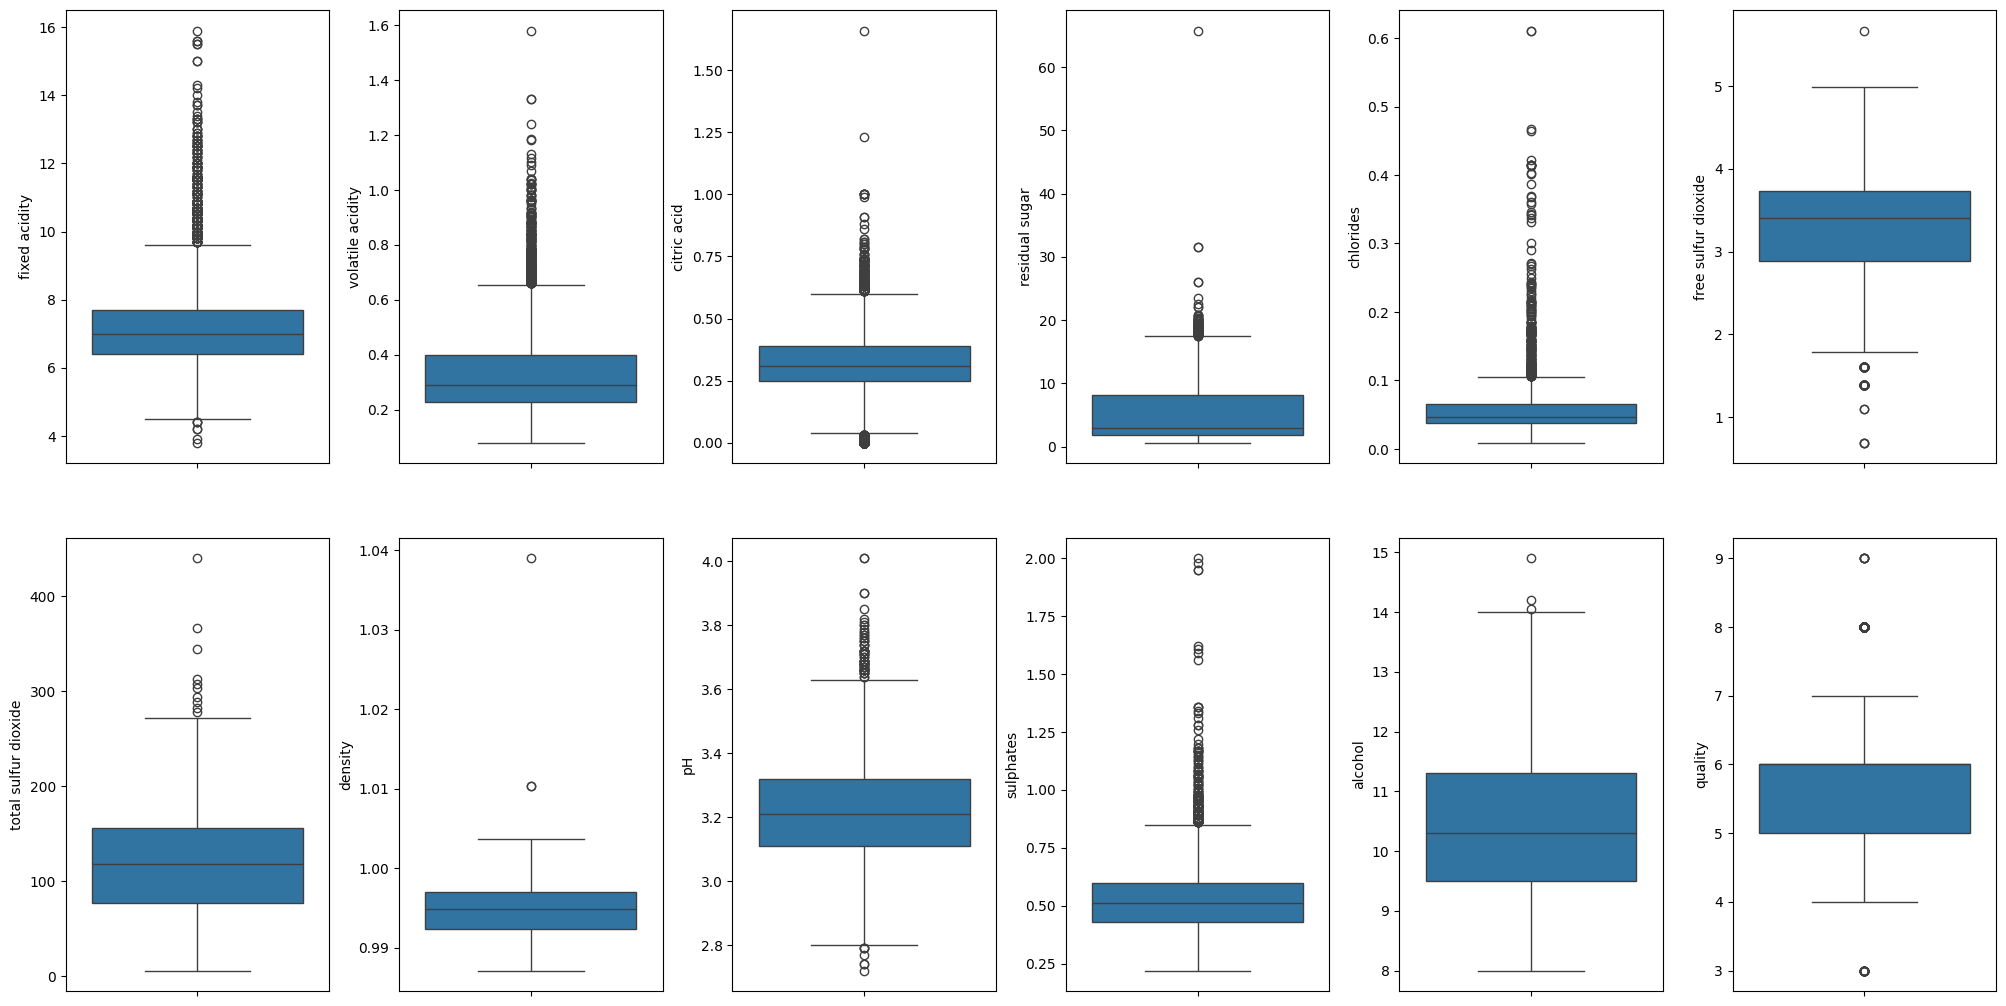

In [19]:
fig, ax = plt.subplots(ncols=6, nrows=2, figsize=(20,10))
index = 0
ax = ax.flatten()

for col, value in df_clean.items(): # Call the items() method to iterate
  if col != 'color':
    sns.boxplot(y=col, data=df, ax=ax[index])
    index += 1

plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)
plt.show()

## **CLASS IMBALANCEMENT**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [21]:
le = LabelEncoder()
df_clean['color'] = le.fit_transform(df_clean['color'])  # red=0, white=1

In [22]:
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

In [23]:
# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Find the minimum number of samples in any class in the training set
min_samples = y_train.value_counts().min()

# If min_samples is less than the default k_neighbors (5), set k_neighbors to min_samples - 1 (if min_samples > 1)
# Otherwise, keep the default k_neighbors or a suitable value.
# SMOTE requires at least 2 samples to create synthetic samples.
k_neighbors = min(5, min_samples - 1) if min_samples > 1 else 1

# Exclude the 'color' column before applying SMOTE
X_train_numeric = X_train.drop('color', axis=1)

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train_numeric, y_train)

In [25]:
# Mostramos la nueva distribución de clases
print("Distribución original de 'quality':")
print(y_train.value_counts())
print("\nDistribución balanceada con SMOTE:")
print(pd.Series(y_train_res).value_counts())

Distribución original de 'quality':
quality
6    2269
5    1710
7     863
4     173
8     154
3      24
9       4
Name: count, dtype: int64

Distribución balanceada con SMOTE:
quality
5    2269
7    2269
6    2269
8    2269
3    2269
4    2269
9    2269
Name: count, dtype: int64


In [26]:
X_color = df_clean.drop('color', axis=1)
y_color = df_clean['color']

In [27]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_color, y_color, test_size=0.2, random_state=42, stratify=y_color)

In [28]:
# Encontramos el mínimo número de muestras en cualquier clase
min_samples_c = y_train_c.value_counts().min()

In [29]:
# Ajustamos k_neighbors para evitar errores si hay muy pocas muestras
k_neighbors_c = min(5, min_samples_c - 1) if min_samples_c > 1 else 1

In [30]:
# Aplicamos SMOTE a 'color'
smote_color = SMOTE(random_state=42, k_neighbors=k_neighbors_c)
X_train_c_res, y_train_c_res = smote_color.fit_resample(X_train_c, y_train_c)

In [31]:
print("Distribución original de 'color':")
print(y_train_c.value_counts())
print("\nDistribución balanceada con SMOTE (color):")
print(pd.Series(y_train_c_res).value_counts())

Distribución original de 'color':
color
1    3918
0    1279
Name: count, dtype: int64

Distribución balanceada con SMOTE (color):
color
1    3918
0    3918
Name: count, dtype: int64


In [32]:
# Mostramos la nueva distribución DE QUALITY
print("Distribución original de 'quality':")
print(y_train.value_counts())
print("\nDistribución balanceada con SMOTE:")
print(pd.Series(y_train_res).value_counts())

# Mostramos la nueva distribución DE COLOR
print("Distribución original de 'color':")
print(y_train_c.value_counts())
print("\nDistribución balanceada con SMOTE (color):")
print(pd.Series(y_train_c_res).value_counts())


Distribución original de 'quality':
quality
6    2269
5    1710
7     863
4     173
8     154
3      24
9       4
Name: count, dtype: int64

Distribución balanceada con SMOTE:
quality
5    2269
7    2269
6    2269
8    2269
3    2269
4    2269
9    2269
Name: count, dtype: int64
Distribución original de 'color':
color
1    3918
0    1279
Name: count, dtype: int64

Distribución balanceada con SMOTE (color):
color
1    3918
0    3918
Name: count, dtype: int64


## **Model Training**

In [ ]:
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

In [35]:
# classify function
from sklearn.model_selection import cross_val_score, train_test_split
def classify(model, X, y):
  x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
  #train the model
  model.fit(x_train, y_train)
  print('Accuracy: ', model.score(x_test, y_test)*100)
  # cross validation
  score = cross_val_score(model, X, y, cv=5)
  print('Cross validation score: ', np.mean(score)*100)


In [36]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
classify(model, X_train_res, y_train_res)

Accuracy:  36.11181062704608
Cross validation score:  33.243283153712646


In [37]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
classify(model, X_train_res, y_train_res)

Accuracy:  80.60941828254848
Cross validation score:  80.61460322897018


In [38]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
classify(model, X_train_res, y_train_res)

Accuracy:  88.59229413246034
Cross validation score:  88.65469618297128


In [39]:
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
classify(model, X_train_res, y_train_res)

Accuracy:  89.77587509443465
Cross validation score:  89.76909763103669


In [41]:
import xgboost as xgb
model = xgb.XGBClassifier()
# Adjust the target variable to be zero-indexed
y_encoded = y_train_res - y_train_res.min()
classify(model, X_train_res, y_encoded)

Accuracy:  87.86199949634853
Cross validation score:  87.60325909857454


In [40]:
import lightgbm as lgb
model = lgb.LGBMClassifier()
classify(model, X_train_res, y_train_res)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2804
[LightGBM] [Info] Number of data points in the train set: 11912, number of used features: 11
[LightGBM] [Info] Start training from score -1.937550
[LightGBM] [Info] Start training from score -1.960540
[LightGBM] [Info] Start training from score -1.968322
[LightGBM] [Info] Start training from score -1.939300
[LightGBM] [Info] Start training from score -1.945742
[LightGBM] [Info] Start training from score -1.941053
[LightGBM] [Info] Start training from score -1.929425
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy:  87.383530596827
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead 